# Getting Started — CPI Data Exploration

A short warm-up that demonstrates the data service layer using three
Canadian CPI series with deliberately different dynamics:

| Series | Why it's here |
|---|---|
| `cpi_all_items_canada` | The headline. Smooth trend, a useful baseline for comparison. |
| `cpi_gasoline_canada` | **The getting-started target.** Violently volatile (2008 collapse, 2014–16 OPEC decline, 2020 COVID crash, 2022 surge). |
| `cpi_shelter_canada` | Sticky, persistent trend with a dramatic 2021–24 regime shift — a good "try this next" alternate. |

`scripts/fetch_cpi.py` registers all 47 product-group series available in
StatCan table 18-10-0004-11.  This notebook selects three of them to keep
the first look uncluttered.  Swap in any other series from the script to
explore further.

**Before running this notebook**, populate the local data cache:

```bash
uv run python scripts/fetch_cpi.py
```

After that, no network calls are made — the notebook reads entirely from
the local cache, which is what the `CutoffEnforcer` discipline requires.

In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.adapters import StatCanAdapter
from aieng.forecasting.evaluation import ForecastingTask

## 1. Build the DataService

Register the three focus series.  This reads from the local stats-can
cache — run `scripts/fetch_cpi.py` first if the cache is empty.

In [2]:
CPI_TABLE_ID = "18-10-0004-11"
CACHE_DIR = Path("../../../data/statcan")

# (series_id, StatCan product-group label, short label)
CPI_SERIES = [
    ("cpi_all_items_canada", "All-items", "All-items"),
    ("cpi_gasoline_canada", "Gasoline", "Gasoline"),
    ("cpi_shelter_canada", "Shelter", "Shelter"),
]

svc = DataService()

for series_id, product_group, short_label in CPI_SERIES:
    adapter = StatCanAdapter(
        table_id=CPI_TABLE_ID,
        member_filter={"GEO": "Canada", "Products and product groups": product_group},
        cache_dir=CACHE_DIR,
    )
    metadata = SeriesMetadata(
        series_id=series_id,
        description=f"CPI {short_label}, Canada (2002=100)",
        source="StatCan",
        units="Index 2002=100",
        frequency="MS",
        table_id=CPI_TABLE_ID,
    )
    svc.register(series_id, adapter, metadata)
    print(f"  Registered: {series_id}")

print("\nDone.")

  Registered: cpi_all_items_canada
  Registered: cpi_gasoline_canada
  Registered: cpi_shelter_canada

Done.


## 2. Inspect the registered series

In [3]:
summary = svc.summary()
summary["start"] = summary["start"].dt.strftime("%Y-%m")
summary["end"] = summary["end"].dt.strftime("%Y-%m")
summary

,series_id,description,source,units,frequency,n_obs,start,end
0,cpi_all_items_canada,"CPI All-items, Canada (2002=100)",StatCan,Index 2002=100,MS,1347,1914-01,2026-03
1,cpi_gasoline_canada,"CPI Gasoline, Canada (2002=100)",StatCan,Index 2002=100,MS,927,1949-01,2026-03
2,cpi_shelter_canada,"CPI Shelter, Canada (2002=100)",StatCan,Index 2002=100,MS,571,1978-09,2026-03


## 3. Cutoff filtering — the core discipline

Calling `get_series(series_id, as_of=...)` returns only observations that
were available on or before `as_of`.  This is how backtests and live
forecasts share the same code path — the `as_of` date is the only
difference.  Predictors never deal with this directly; they receive a
`ForecastContext` in which the cutoff is already applied.

In [4]:
cutoff = datetime(2023, 1, 1)
df_cutoff = svc.get_series("cpi_gasoline_canada", as_of=cutoff)

print(f"as_of: {cutoff.date()}")
print(f"Rows returned: {len(df_cutoff)}")
print(f"Latest observation: {df_cutoff['timestamp'].max().date()}")
df_cutoff.tail()

as_of: 2023-01-01
Rows returned: 888
Latest observation: 2022-12-01


,timestamp,value,released_at
883,2022-08-01,245.8,2022-08-22
884,2022-09-01,227.6,2022-09-22
885,2022-10-01,248.6,2022-10-22
886,2022-11-01,239.6,2022-11-22
887,2022-12-01,208.3,2022-12-22


## 4. Plot: the three series side by side

The levels plot highlights the most striking thing about gasoline: its
scale dominates everything else.  The small-multiples view lets each
series speak on its own.

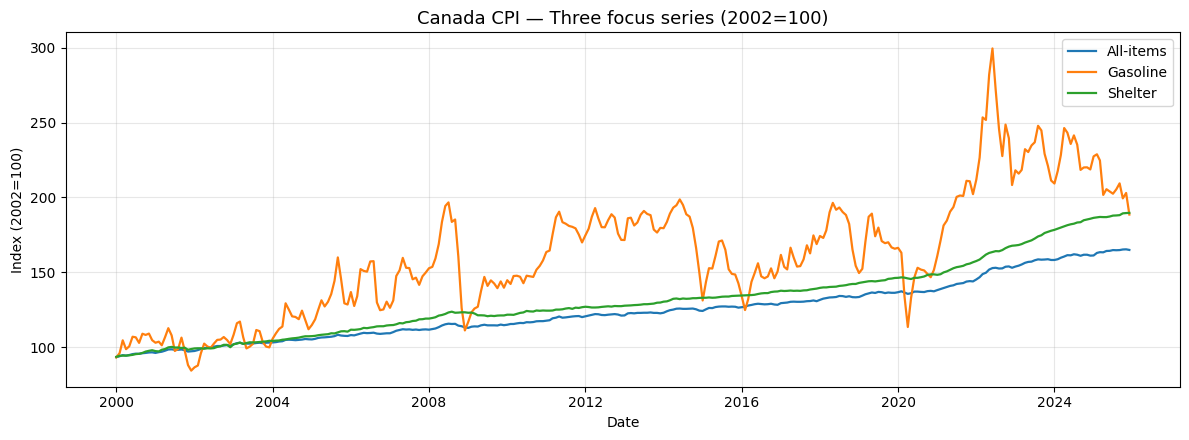

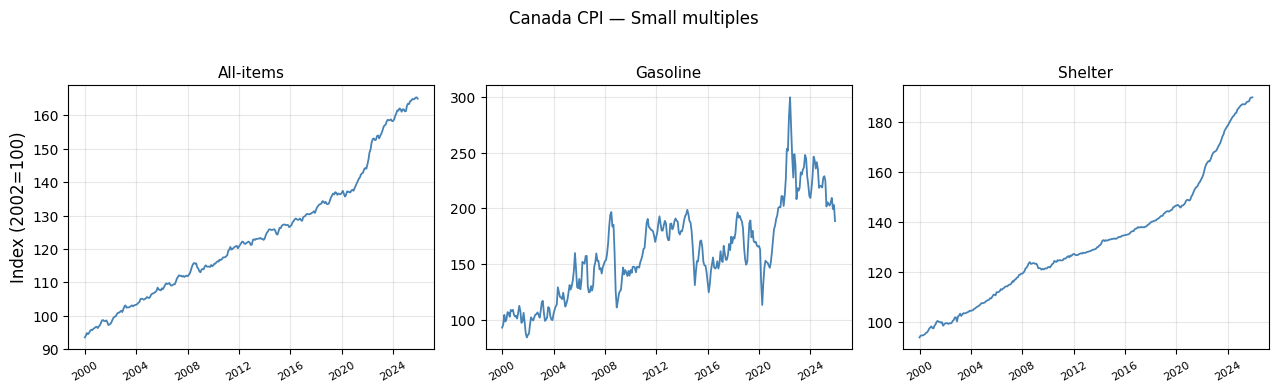

In [5]:
AS_OF = datetime(2026, 1, 1)
PLOT_START = "2000-01"

series_data = {
    series_id: (svc.get_series(series_id, as_of=AS_OF).set_index("timestamp").sort_index().loc[PLOT_START:])
    for series_id, _, __ in CPI_SERIES
}

fig, ax = plt.subplots(figsize=(12, 4.5))
for series_id, _, short_label in CPI_SERIES:
    df = series_data[series_id]
    ax.plot(df.index, df["value"], label=short_label, linewidth=1.6)
ax.set_title("Canada CPI — Three focus series (2002=100)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Index (2002=100)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)
for ax, (series_id, _, short_label) in zip(axes, CPI_SERIES):
    df = series_data[series_id]
    ax.plot(df.index, df["value"], linewidth=1.3, color="steelblue")
    ax.set_title(short_label, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
fig.suptitle("Canada CPI — Small multiples", fontsize=12, y=1.02)
fig.supylabel("Index (2002=100)", x=0.02)
plt.tight_layout()
plt.show()

## 5. Year-over-year change

Derived from the index levels — storing levels and computing changes
on-demand is the right pattern.  Note how gasoline's YoY amplitude dwarfs
shelter and all-items; this is the "why forecasting gasoline is hard"
story in a single chart, and the motivation for picking gasoline as the
getting-started target.

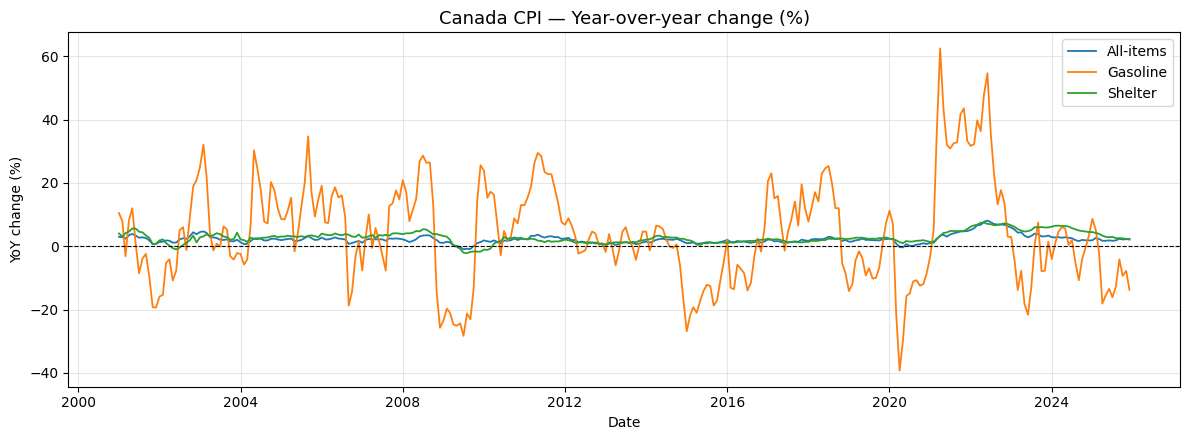

In [6]:
YOY_START = "2000-01"

fig, ax = plt.subplots(figsize=(12, 4.5))
for series_id, _, short_label in CPI_SERIES:
    df = series_data[series_id].loc[YOY_START:].copy()
    df["yoy_pct"] = df["value"].pct_change(12) * 100
    ax.plot(df.index, df["yoy_pct"], label=short_label, linewidth=1.3)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Canada CPI — Year-over-year change (%)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("YoY change (%)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Define a `ForecastingTask`

A `ForecastingTask` specifies the prediction problem without prescribing
how a predictor should solve it.  For completeness, here's what the
getting-started backtest task looks like as a plain Python construction —
the YAML spec in `reference_specs/cpi_gasoline_12m.yaml` is exactly this
plus a window (`start`, `end`, `stride`, `warmup`).

In [7]:
task = ForecastingTask(
    task_id="cpi_gasoline_canada_12m",
    target_series_id="cpi_gasoline_canada",
    horizons=[12],
    frequency="MS",
    description=(
        "Forecast Canada-wide CPI Gasoline (2002=100) 12 months ahead. "
        "Resolution: observed CPI value at the target month-start timestamp."
    ),
)

print(task.model_dump_json(indent=2))

{
  "task_id": "cpi_gasoline_canada_12m",
  "target_series_id": "cpi_gasoline_canada",
  "horizons": [
    12
  ],
  "frequency": "MS",
  "description": "Forecast Canada-wide CPI Gasoline (2002=100) 12 months ahead. Resolution: observed CPI value at the target month-start timestamp.",
  "resolution_fn": "observed_value_at_resolution_timestamp"
}


## Next: `cpi_backtest_demo.ipynb`

That notebook runs the full end-to-end backtest against the reference
spec, compares a naive baseline to AutoARIMA, plots the predictions
against the observed series with 80% CI bands, and walks through where
each predictor fails and why.  Start there after this warm-up.